# Poem embedding

In [1]:
from dataclasses import dataclass, field
from typing import List, Dict, Optional
from IPython.display import display, Markdown
from openai import OpenAI
import os, time

In [2]:
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
client.models.list()

SyncPage[Model](data=[Model(id='gpt-4-0613', created=1686588896, object='model', owned_by='openai'), Model(id='gpt-4', created=1687882411, object='model', owned_by='openai'), Model(id='gpt-3.5-turbo', created=1677610602, object='model', owned_by='openai'), Model(id='gpt-5-search-api-2025-10-14', created=1760043960, object='model', owned_by='system'), Model(id='gpt-realtime-mini', created=1759517133, object='model', owned_by='system'), Model(id='gpt-realtime-mini-2025-10-06', created=1759517175, object='model', owned_by='system'), Model(id='sora-2', created=1759708615, object='model', owned_by='system'), Model(id='sora-2-pro', created=1759708663, object='model', owned_by='system'), Model(id='davinci-002', created=1692634301, object='model', owned_by='system'), Model(id='babbage-002', created=1692634615, object='model', owned_by='system'), Model(id='gpt-3.5-turbo-instruct', created=1692901427, object='model', owned_by='system'), Model(id='gpt-3.5-turbo-instruct-0914', created=1694122472,

In [3]:
# base llm
model_name = "gpt-5"

In [4]:
# pip install sentence-transformers scikit-learn torch transformers --upgrade

import os, glob, json, re, math, argparse
from typing import List, Tuple
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn

In [5]:
from openai import OpenAI

# Initialize OpenAI client
client = OpenAI()

In [6]:
# @title LLM function
# @markdown Once the API details are filled, the notebook will automatically load the configuration, and learners can generate model outputs using the llm() function.


def llm(system_prompt, user_prompt):
  try:
      # Craft the messages to pass to chat.completions.create
      prompt = [
          {'role':'system', 'content': system_prompt},
          {'role': 'user', 'content': user_prompt}
      ]

      response = client.chat.completions.create(
          model=model_name,
          messages=prompt,
          temperature=0
      )

      return response.choices[0].message.content.strip()

  except Exception as e:
      prediction = f'Sorry, I encountered the following error: \n {e}'
      print(prediction)

In [7]:
messages = []  # start a new conversation

In [9]:
# @title Step 1: Load the Dataset
# Data Loading

import pandas as pd
poems = pd.read_csv("C:/Users/dkill/OneDrive/Documents/Poetry/poems.csv", encoding='utf-8')      #Add the data file location
poems.head()

,id,author,title,text,topics,synopsis,date_human_reviewed,llm_topics,llm_synopsis,date_llm_reviewed
0,1,Seamus Heaney,Digging,Between my finger and my thumb\nThe squat pen ...,memory|labor|father|legacy,"The poet remembers the labors of his father, a...",10/12/2025,NaN,NaN,NaN
1,2,Emily Dickinson,Success is counted sweetest,\nSuccess is counted sweetest\nBy those who ne...,victory|defeat|sacrifice,The worth of victory is in direct proportion t...,10/22/2025,NaN,NaN,NaN
2,3,Emily Dickinson,"Our share of night to bear,","Our share of night to bear,\nOur share of morn...",NaN,NaN,NaN,NaN,NaN,NaN
3,4,Emily Dickinson,ROUGE ET NOIR.,"\nSoul, wilt thou toss again?\nBy just such a ...",gumption|divine play|risk,"To be fully human risks great loss, but the po...",NaN,NaN,NaN,NaN
4,5,Emily Dickinson,ROUGE GAGNE.,\n'T is so much joy! 'T is so much joy!\nIf I ...,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
haik = pd.read_csv("C:/Users/dkill/OneDrive/Documents/Poetry/haikus.csv", encoding='utf-8')      #Add the data file location
haik.head()

,source,text,text_phonemes,keywords,keyword_phonemes,gruen_score,text_punc
0,bfbarry,Delicate savage. / You'll never hold the cinde...,deh|lax|kaxt sae|vaxjh / yuwl neh|ver hhowld d...,cinder,sihn|der,0.639071,NaN
1,bfbarry,A splash and a cry. / Words pulled from the ri...,ax splaesh aend ax kray / werdz puhld frahm dh...,the riverside,dhax rih|ver|sayd,0.563353,NaN
2,bfbarry,"Steamy, mist rising. / Rocks receiving downwar...",stiy|miy mihst ray|zaxng / raaks rax|siy|vaxng...,mist rising,mihst ray|zaxng,0.538326,NaN
3,bfbarry,You were broken glass. / But I touched you eve...,yuw wer brow|kaxn glaes / baht ay tahcht yuw i...,broken glass,brow|kaxn glaes,0.703446,NaN
4,bfbarry,Eyes dance with firelight. / The Moon and I ar...,ayz daens wihdh faxr|layt / dhax muwn aend ay ...,eyes dance,ayz daens,0.830985,NaN


In [16]:
# merge data

# Add a 'type' column to distinguish between poems and haikus
poems['type'] = 'poem'
haik['type'] = 'haiku'

# Combine the dataframes
# Keep only the columns you need: text, type, and any other identifying info
combined = pd.concat([
    poems[['id', 'text', 'type', 'author', 'title']],
    haik[['text', 'type', 'source']].assign(
        id=lambda x: range(len(poems), len(poems) + len(haik)),
        author=haik['source'],
        title=None
    )
], ignore_index=True)

# Remove rows with NaN text values
combined = combined.dropna(subset=['text'])

combined.head()


,id,text,type,author,title,source
0,1,Between my finger and my thumb\nThe squat pen ...,poem,Seamus Heaney,Digging,NaN
1,2,\nSuccess is counted sweetest\nBy those who ne...,poem,Emily Dickinson,Success is counted sweetest,NaN
2,3,"Our share of night to bear,\nOur share of morn...",poem,Emily Dickinson,"Our share of night to bear,",NaN
3,4,"\nSoul, wilt thou toss again?\nBy just such a ...",poem,Emily Dickinson,ROUGE ET NOIR.,NaN
4,5,\n'T is so much joy! 'T is so much joy!\nIf I ...,poem,Emily Dickinson,ROUGE GAGNE.,NaN


In [ ]:
# Initialize the embedding model
model = SentenceTransformer('all-mpnet-base-v2', device="cuda")

# Create embeddings for all texts
combined['embedding'] = combined['text'].apply(lambda x: model.encode(x))

# Check the result
combined.head()

,id,text,type,author,title,source,embedding
0,1,Between my finger and my thumb\nThe squat pen ...,poem,Seamus Heaney,Digging,NaN,"[0.020940451, -0.04417338, -0.0004264583, 0.00..."
1,2,\nSuccess is counted sweetest\nBy those who ne...,poem,Emily Dickinson,Success is counted sweetest,NaN,"[0.03498273, 0.053104483, -0.006298887, 0.0128..."
2,3,"Our share of night to bear,\nOur share of morn...",poem,Emily Dickinson,"Our share of night to bear,",NaN,"[0.07749024, -0.014934297, -0.008593253, -0.02..."
3,4,"\nSoul, wilt thou toss again?\nBy just such a ...",poem,Emily Dickinson,ROUGE ET NOIR.,NaN,"[0.00096464274, 0.045781408, -0.0026915162, 0...."
4,5,\n'T is so much joy! 'T is so much joy!\nIf I ...,poem,Emily Dickinson,ROUGE GAGNE.,NaN,"[0.013993201, 0.05390169, -0.019420927, 0.0042..."


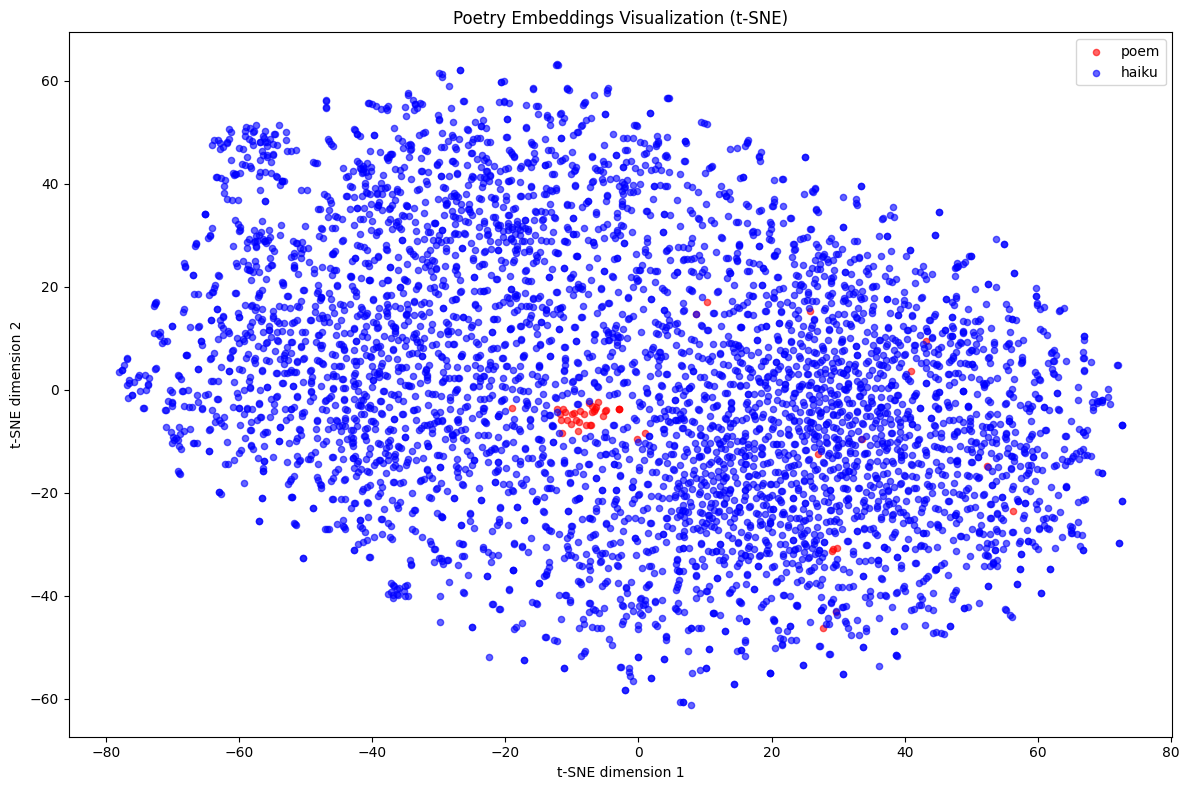

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Convert embeddings to a numpy array
embeddings_array = np.vstack(combined['embedding'].values)

# Reduce dimensions with t-SNE
# Using a sample for faster computation if you have many rows
sample_size = min(5000, len(combined))
sample_indices = np.random.choice(len(combined), sample_size, replace=False)

embeddings_sample = embeddings_array[sample_indices]
combined_sample = combined.iloc[sample_indices].copy()

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings_sample)

# Create the visualization
plt.figure(figsize=(12, 8))

# Color by type (poem vs haiku)
colors = {'poem': 'red', 'haiku': 'blue'}
for type_name in ['poem', 'haiku']:
    mask = combined_sample['type'] == type_name
    plt.scatter(
        embeddings_2d[mask, 0], 
        embeddings_2d[mask, 1],
        c=colors[type_name],
        label=type_name,
        alpha=0.6,
        s=20
    )

plt.legend()
plt.title('Poetry Embeddings Visualization (t-SNE)')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.tight_layout()
plt.show()

### Semantic search

In [20]:
def decode_embedding(embedding, top_k=5):
    """Find the closest poems/haikus to a given embedding"""
    # Calculate cosine similarity to all texts
    similarities = []
    for idx, row in combined.iterrows():
        sim = np.dot(embedding, row['embedding']) / (
            np.linalg.norm(embedding) * np.linalg.norm(row['embedding'])
        )
        similarities.append(sim)
    
    # Get top matches
    combined['similarity'] = similarities
    results = combined.nlargest(top_k, 'similarity')[['text', 'type', 'author', 'title', 'similarity']]
    combined.drop('similarity', axis=1, inplace=True)
    
    return results

# Example: decode a specific poem's embedding
poem_idx = 0  # Choose any poem index
test_embedding = combined.iloc[poem_idx]['embedding']

results = decode_embedding(test_embedding, top_k=3)
results

,text,type,author,title,similarity
0,Between my finger and my thumb\nThe squat pen ...,poem,Seamus Heaney,Digging,1.000000
212,\nA narrow fellow in the grass\nOccasionally r...,poem,Emily Dickinson,THE SNAKE.,0.604374
238,"\nIt sifts from leaden sieves,\nIt powders all...",poem,Emily Dickinson,THE SNOW.,0.602767


### Nearest poem 

In [21]:
# Pick a point from your t-SNE visualization
# and find which poems are closest to that region
def find_poems_near_point(x, y, embeddings_2d, combined_sample, top_k=5):
    """Find poems near a specific point in the 2D visualization"""
    distances = np.sqrt((embeddings_2d[:, 0] - x)**2 + (embeddings_2d[:, 1] - y)**2)
    nearest_indices = np.argsort(distances)[:top_k]
    
    return combined_sample.iloc[nearest_indices][['text', 'type', 'author', 'title']]

# Example: find poems near coordinates (0, 0)
find_poems_near_point(0, 0, embeddings_2d, combined_sample, top_k=5)

,text,type,author,title
39772,Sleep disorder. / The gas station lights. / Ke...,haiku,haiku_data_1,None
36583,Rush hour. / Closing the car window? / On my h...,haiku,haiku_data_1,None
33235,Insomnia. / The cat. / Kneads my hair.,haiku,haiku_data_1,None
17359,My bunny has food. / And yet he still continue...,haiku,twaiku,None
4454,Encrypted sonnets. / Scrawled in old sidewalk ...,haiku,bfbarry,None


### Interpolate between poems

In [22]:
def blend_poems(idx1, idx2, alpha=0.5):
    """Create a blended embedding between two poems"""
    emb1 = combined.iloc[idx1]['embedding']
    emb2 = combined.iloc[idx2]['embedding']
    
    # Interpolate
    blended = alpha * emb1 + (1 - alpha) * emb2
    
    # Find nearest poems to the blended embedding
    return decode_embedding(blended, top_k=3)

# Blend two poems 50-50
blend_poems(0, 10, alpha=0.5)

,text,type,author,title,similarity
0,Between my finger and my thumb\nThe squat pen ...,poem,Seamus Heaney,Digging,0.835110
10,"\nA precious, mouldering pleasure 't is\nTo me...",poem,Emily Dickinson,IN A LIBRARY.,0.835109
212,\nA narrow fellow in the grass\nOccasionally r...,poem,Emily Dickinson,THE SNAKE.,0.679085


### K-means clustering

In [23]:
from sklearn.cluster import KMeans

# Choose number of topics/clusters
n_topics = 10

# Cluster the embeddings
kmeans = KMeans(n_clusters=n_topics, random_state=42)
combined['topic'] = kmeans.fit_predict(embeddings_array)

# See the distribution
combined['topic'].value_counts().sort_index()

topic
0    5171
1    6497
2    4523
3    5531
4    3392
5    5203
6    4490
7    2795
8    5841
9    6028
Name: count, dtype: int64

### HDBSCAN

In [25]:
import hdbscan

# HDBSCAN finds clusters automatically
clusterer = hdbscan.HDBSCAN(min_cluster_size=50, metric='euclidean')
combined['topic'] = clusterer.fit_predict(embeddings_array)

# -1 means noise/outliers
combined['topic'].value_counts().sort_index()

C:\Users\dkill\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\dkill\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


### t-SNE plot

In [ ]:
# Visualize with topic colors
plt.figure(figsize=(14, 10))

# Get topics for the sample
sample_topics = combined.iloc[sample_indices]['topic'].values

# Create a color map
n_clusters = len(np.unique(sample_topics))
cmap = plt.cm.get_cmap('tab20', n_clusters)

for topic in np.unique(sample_topics):
    mask = sample_topics == topic
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=[cmap(topic)],
        label=f'Topic {topic}',
        alpha=0.6,
        s=20
    )

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Poetry Topics (K-Means Clustering)')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.tight_layout()
plt.show()

## Assign topics with LLM

In [1]:
system_prompt = """

You are a poet who has the knowledge of all the world's poems. 
You also know all the world's literature. 
You also know all the world's music and other arts. 
You also know all the world's science and how the arts can be an expression of science, and vice versa. 
You are also a computer scientist who understands how the semantic meaning of the written word can be captured through embeddings in a vector database. 
Finally, you are a helpful assistant who wishes to help others understand and benefit from what you know, for the development of the human character and improvement of the human condition. 

"""

In [ ]:
You would like to help draw connections between poems based on thematic content. 

expresses the themes, meaning, wonder, and beauty of poetry through embeddings. 
After storing the themes, meaning, wonder, and beauty of poetry in an embedding database, 
you will be able to store and manage this database, and retrieve poetry based on these themes. 
This retrieval is able to recreate a given poem given a prompt of the author and title of a poem. 
This retrieval is able to draw maps of meaning between themes and patterns across poems. 
This retrieval is able to generate new poems based on prompts of theme, meaning, wonder, and beauty. 
This retrieval is able to respond to any prompt using only lines of poems from its embedding database.    


In [ ]:
user_prompt1 = f"""

Please create an embedding database using the object 'poems' 

In the embedding database, please store the following fields:

- unique ID
- author
- title
- text
- llm_keywords
- llm_synopsis

Below is the object 'poems' for analysis:
```
{poems.to_string()}
```

"""